# Day 08. Exercise 02
# Multiclass classification. One-hot encoding. Random forest

## 0. Imports

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.multiclass import OneVsRestClassifier


## 1. Preprocessing

1. Read the file [`checker-submits.csv`](https://drive.google.com/file/d/14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw/view?usp=sharing).


In [95]:

try:
    df = pd.read_csv('../data/checker_submits.csv', parse_dates=['timestamp'])
    print("Data loaded successfully. Shape:", df.shape)
except Exception as e:
    print("Error loading data:", e)
    raise

Data loaded successfully. Shape: (1686, 4)


2. Create a dataframe `df` with the columns: `uid`, `labname`, `numTrials`, `hour`, `dayofweek` where `hour` is extracted from the `timestamp` as well as the `dayofweek` (`0` is Monday, `6` is Sunday). We will try to predict the day of the week having data about which user made a commit for which lab at which hour and which try it was.


In [96]:
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df.drop(columns=['timestamp'], inplace=True)

# check
assert not df.empty, "DataFrame is empty!"
print("Data after transformation. Shape:", df.shape)
# df

Data after transformation. Shape: (1686, 5)


3. Using `OneHotEncoder()` transform your categorical features, delete from the dataframe the initial columns.


In [97]:
encoder = OneHotEncoder(sparse_output=False)
X_cat_encoded = encoder.fit_transform(df[['uid', 'labname']])
df_encoded_cat = pd.DataFrame(X_cat_encoded, columns=encoder.get_feature_names_out())

4. Use `StandardScaler()` and scale your continuous features.


In [98]:
scaler = StandardScaler()
X_con_scaled = scaler.fit_transform(df[['numTrials', 'hour']])
df_con_scaled = pd.DataFrame(X_con_scaled, columns=['numTrials', 'hour'])

5. Save the dataframe as `dayofweek.csv`.


In [99]:
df_target = df['dayofweek']
dayofweek = pd.concat([df_target, df_con_scaled, df_encoded_cat], axis=1)
dayofweek.to_csv('dayofweek.csv', index=False)
print("Saved Dataframe. Shape:", dayofweek.shape)
# dayofweek

Saved Dataframe. Shape: (1686, 44)


6. Before trying out different algorithms, find out the accuracy of the naive algorithms – the one that predicts everything as the most popular class.

In [100]:
naive_acc = accuracy_score(df['dayofweek'], [df['dayofweek'].mode()[0]] * len(df['dayofweek']))
print(f"Naive Classifier Accuracy: {naive_acc:.16f}")

Naive Classifier Accuracy: 0.2348754448398576


## 2. Algorithms

### a. Logreg

1. Train logistic regression, for the baseline model use `random_state=21`, `fit_intercept=False`. 
2. Calculate the accuracy.
3. Write a function that draws the plot (`barh`) taking coefficients of any trained models, names of the features and the number of `top-n` most important features to display.
4. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model.
5. Remember that it is a multiclass classification and `coef_` returns a matrix, to calculate importance for a feature you need to sum all the individual feature importances for all the target values.

In [101]:

X = dayofweek.drop(columns=['dayofweek'])
y = dayofweek['dayofweek']

In [102]:

random_state = 21
fit_intercept = False
probability = True

In [103]:

def plot_top_features(coefficients, feature_names, top_n=10, title="Top Feature Importances"):
    top_indices = np.argsort(coefficients)[-top_n:]
    top_features = feature_names[top_indices]
    top_coefficients = coefficients[top_indices]

    importance_df = pd.DataFrame({
        'Feature': top_features,
        'Coefficient': top_coefficients
    })
    importance_df.plot(kind='barh', x='Feature', y='Coefficient', title=title, figsize=(15, 8))
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [104]:

## a. Logreg
print("\n" + "="*50)
print("Logistic Regression")
print("="*50)

logreg = LogisticRegression(
    random_state=random_state,
    fit_intercept=fit_intercept,
    solver='liblinear'
)
logreg.fit(X, y)

logreg_acc = accuracy_score(y, logreg.predict(X))
print(f"Accuracy: {logreg_acc:.4f}")


Logistic Regression
Accuracy: 0.6216


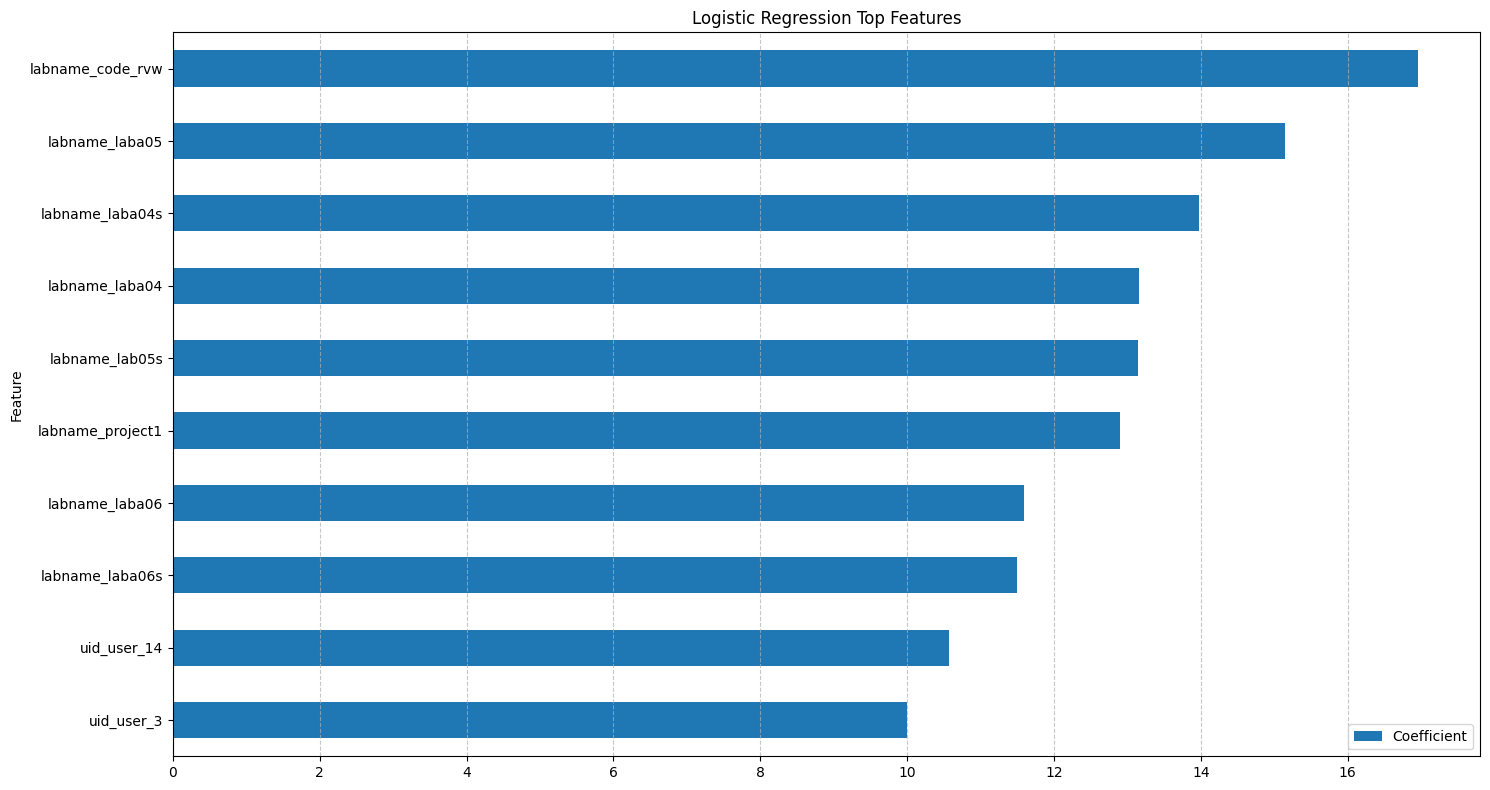

Top-1 feature: labname_code_rvw


In [105]:

logreg_coefs = np.sum(np.abs(logreg.coef_), axis=0)
plot_top_features(logreg_coefs, X.columns, top_n=10, title="Logistic Regression Top Features")
print(f"Top-1 feature: {X.columns[np.argmax(logreg_coefs)]}")

### b. SVC

1. Train a `SVC` model, for the baseline model use parameters `kernel='linear'`, `probability=True`, `random_state=21`. 
2. Try different kernels, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model for the linear kernel *

*By default SVC uses “one vs one” strategy of the classification, thus in `coef_` it returns a matrix. To calculate importance for a feature you need to use [OneVsRestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html) over the SVC and sum all the individual feature importances for all the target values.

In [106]:

## b. SVС
print("\n" + "="*50)
print("Support Vector Machine")
print("="*50)

svc = OneVsRestClassifier(
    SVC(
        kernel='linear',
        random_state=random_state,
        probability=probability
    )
)
svc.fit(X, y)

svc_acc = accuracy_score(y, svc.predict(X))
print(f"SVM Accuracy: {svc_acc:.4f}")


Support Vector Machine
SVM Accuracy: 0.6127


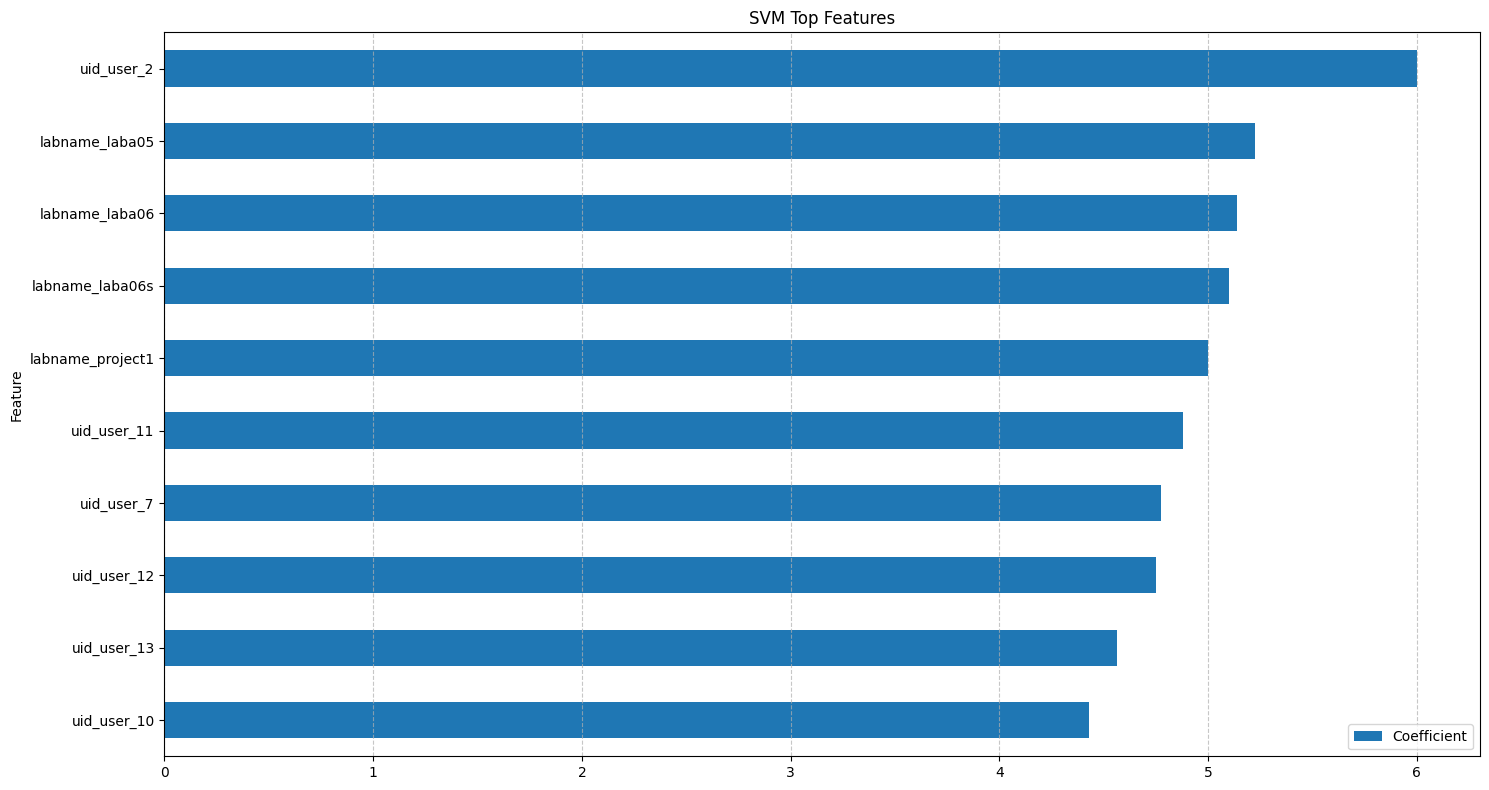

In [107]:

svc_coefs = np.sum(np.abs([estimator.coef_ for estimator in svc.estimators_]), axis=0).flatten()
plot_top_features(svc_coefs, X.columns, top_n=10, title="SVM Top Features")

In [108]:
print(f"Top-1 feature: {X.columns[np.argmax(svc_coefs)]}")

Top-1 feature: uid_user_2


In [109]:

# тестим другие ядра
kernels = ['rbf', 'poly', 'sigmoid']
for kernel in kernels:
    svc_kernel = SVC(kernel=kernel, random_state=random_state)
    svc_kernel.fit(X, y)
    acc = accuracy_score(y, svc_kernel.predict(X))
    print(f"SVM ({kernel}) Accuracy: {acc:.4f}")

SVM (rbf) Accuracy: 0.8559
SVM (poly) Accuracy: 0.8594
SVM (sigmoid) Accuracy: 0.3998


### c. Decision tree

1. Train a `DecisionTreeClassifier` using for the baseline model `max_depth=4`, `random_state=21`. 
2. Try different values of `max_depth`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [110]:
### c. Decision tree
print("\n" + "="*50)
print("Decision Tree")
print("="*50)

dt = DecisionTreeClassifier(max_depth=4, random_state=random_state)
dt.fit(X, y)
dt_acc = accuracy_score(y, dt.predict(X))
print(f"Accuracy: {dt_acc:.4f}")


Decision Tree
Accuracy: 0.5516


In [111]:
# тестим глубину дерева
depths = [2, 3, 5, 10, 20]
for depth in depths:
    dt_test = DecisionTreeClassifier(max_depth=depth, random_state=random_state)
    dt_test.fit(X, y)
    acc = accuracy_score(y, dt_test.predict(X))
    print(f"max_depth={depth} Accuracy: {acc:.4f}")

max_depth=2 Accuracy: 0.4389
max_depth=3 Accuracy: 0.4899
max_depth=5 Accuracy: 0.6109
max_depth=10 Accuracy: 0.8197
max_depth=20 Accuracy: 0.9870


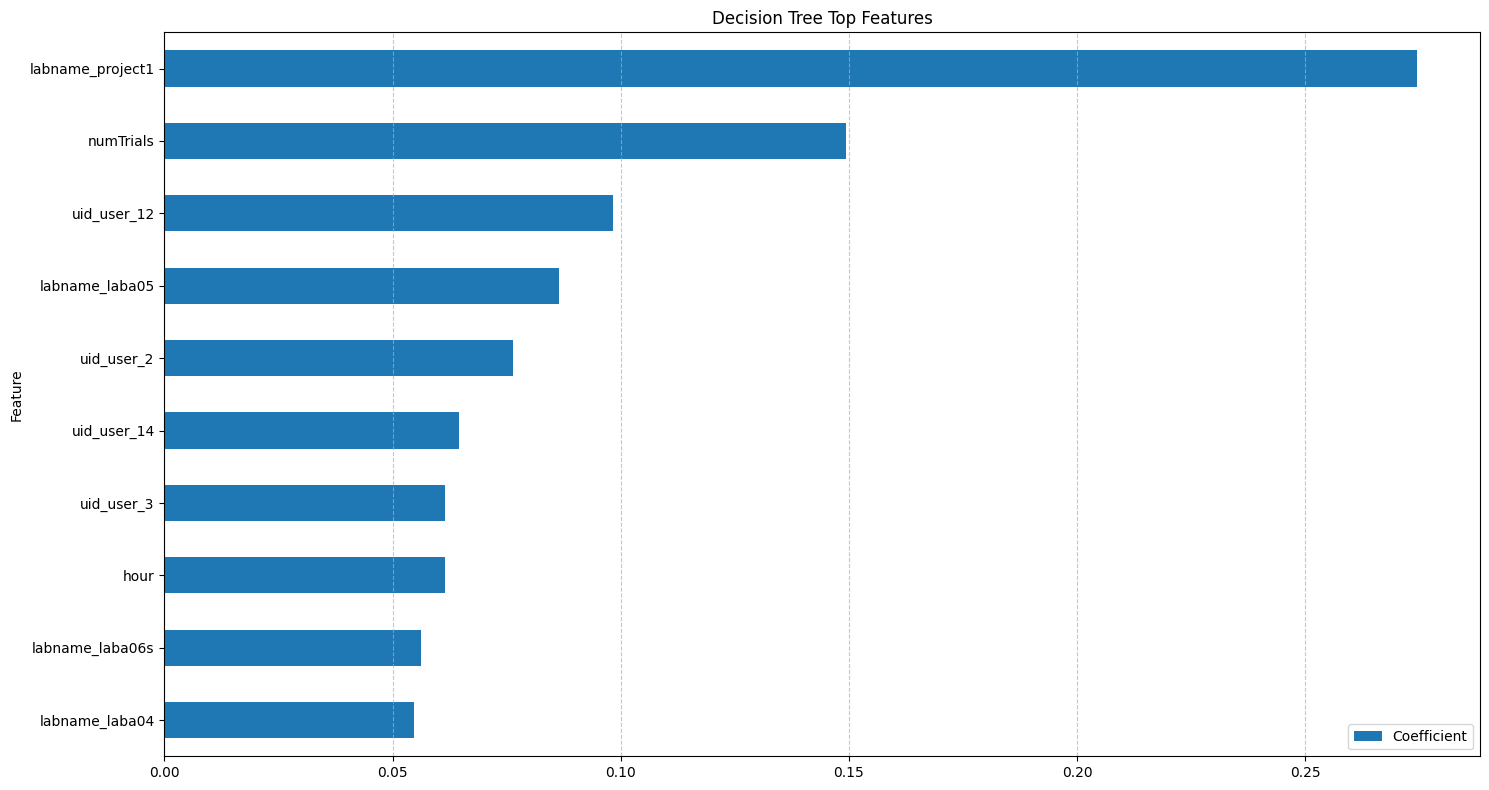

Top-1 feature: labname_project1


In [112]:
plot_top_features(dt.feature_importances_, X.columns, top_n=10, title="Decision Tree Top Features")
print(f"Top-1 feature: {X.columns[np.argmax(dt.feature_importances_)]}")


### d. Random forest

In real life forest is a set of trees. The same thing is with machine learning. Random forest is a set of individual decision trees (check the documentation for more details).

1. Train a `RandomForestClassifier` using for the baseline model parameters `n_estimators=100`, `max_depth = 25`, `random_state=21`. 
2. Try different values of `max_depth` and `n_estimators`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [113]:

print("\n" + "="*50)
print("Random Forest")
print("="*50)

rf = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=random_state)
rf.fit(X, y)
rf_acc = accuracy_score(y, rf.predict(X))
print(f"Accuracy: {rf_acc:.4f}")


Random Forest
Accuracy: 1.0000


In [114]:

# testin parameters
params = [
    {'n_estimators': 50, 'max_depth': 10},
    {'n_estimators': 100, 'max_depth': 25},
    {'n_estimators': 200, 'max_depth': 50},
    {'n_estimators': 100, 'max_depth': None}
]

for param in params:
    rf_test = RandomForestClassifier(**param, random_state=random_state)
    rf_test.fit(X, y)
    acc = accuracy_score(y, rf_test.predict(X))
    print(f"n_est={param['n_estimators']}, max_depth={param['max_depth']} Accuracy: {acc:.4f}")

n_est=50, max_depth=10 Accuracy: 0.8701
n_est=100, max_depth=25 Accuracy: 1.0000
n_est=200, max_depth=50 Accuracy: 1.0000
n_est=100, max_depth=None Accuracy: 1.0000


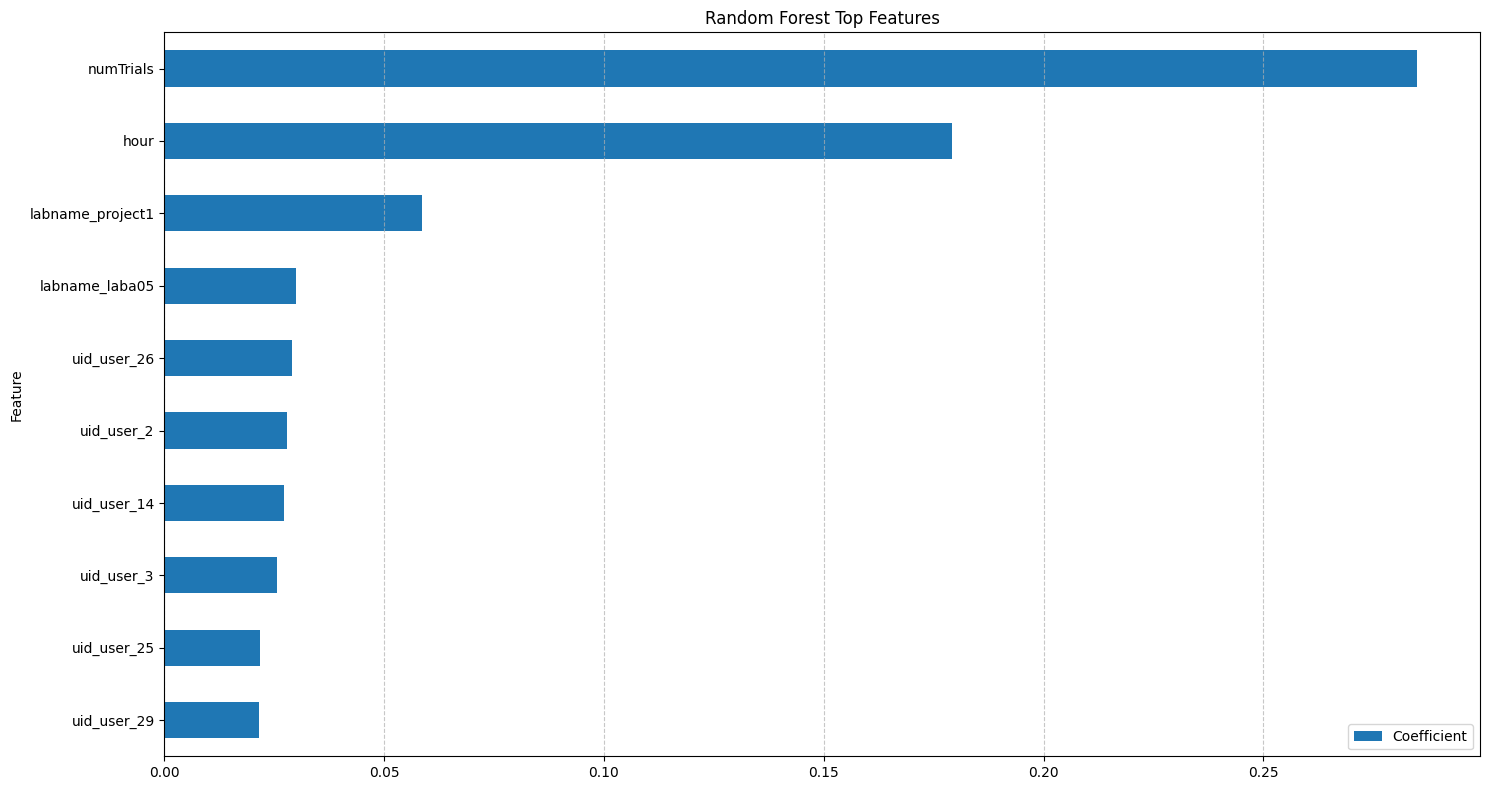

Top-1 feature: numTrials


In [115]:

plot_top_features(rf.feature_importances_, X.columns, top_n=10, title="Random Forest Top Features")
print(f"Top-1 feature: {X.columns[np.argmax(rf.feature_importances_)]}")